In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OPENBLAS_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
print("IPython: Thread limits set to 4")

IPython: Thread limits set to 4


In [6]:
# train_gin_node_fixed.py
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

NODE_CSV  = "GNNDatasets/node.csv"
EDGE_CSV  = "GNNDatasets/node_edges.csv"
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ----------------------------- Load nodes -----------------------------
nodes_df = pd.read_csv(NODE_CSV)

label_col = None
for cand in ["label", "is_trojan", "trojan", "target"]:
    if cand in nodes_df.columns:
        label_col = cand; break
if label_col is None:
    nodes_df["label"] = nodes_df["circuit_name"].astype(str).str.contains("__trojan_").astype(int)
    label_col = "label"

nodes_df["uid"] = nodes_df["circuit_name"].astype(str) + "::" + nodes_df["node"].astype(str)

feat_df = nodes_df.copy()
if "gate_type" in feat_df.columns:
    gate_oh = pd.get_dummies(feat_df["gate_type"], prefix="gt")
    feat_df = pd.concat([feat_df.drop(columns=["gate_type"]), gate_oh], axis=1)

exclude = {"uid","node","circuit_name",label_col}
num_cols = [c for c in feat_df.columns if c not in exclude and pd.api.types.is_numeric_dtype(feat_df[c])]
X = feat_df[num_cols].fillna(0.0).values.astype(np.float32)
y = nodes_df[label_col].values.astype(np.int64)

# ----------------------------- Load edges; add missing nodes -----------------------------
edges_df = pd.read_csv(EDGE_CSV)
edges_df["src_uid"] = edges_df["circuit_name"].astype(str) + "::" + edges_df["src"].astype(str)
edges_df["dst_uid"] = edges_df["circuit_name"].astype(str) + "::" + edges_df["dst"].astype(str)

known_uids = set(nodes_df["uid"])
edge_uids = set(edges_df["src_uid"]).union(set(edges_df["dst_uid"]))
missing = list(edge_uids - known_uids)

if missing:
    zero_row = np.zeros((1, X.shape[1]), dtype=np.float32)
    addX = np.repeat(zero_row, len(missing), axis=0)
    addY = -1*np.ones(len(missing), dtype=np.int64)
    add_df = pd.DataFrame({
        "uid": missing,
        "circuit_name": [u.split("::",1)[0] for u in missing],
        "node": [u.split("::",1)[1] for u in missing],
        label_col: addY
    })
    X = np.vstack([X, addX])
    y = np.concatenate([y, addY])
    nodes_df = pd.concat([nodes_df, add_df], ignore_index=True)

uid_to_idx = {u:i for i,u in enumerate(nodes_df["uid"].tolist())}
src_idx = edges_df["src_uid"].map(uid_to_idx).dropna().astype(int).values
dst_idx = edges_df["dst_uid"].map(uid_to_idx).dropna().astype(int).values
edge_index = np.stack([np.concatenate([src_idx, dst_idx]),
                       np.concatenate([dst_idx, src_idx])], axis=0)

# ----------------------------- Scale features -----------------------------
labeled_mask_np = (y >= 0)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[labeled_mask_np] = scaler.fit_transform(X_scaled[labeled_mask_np])
if (~labeled_mask_np).any():
    X_scaled[~labeled_mask_np] = (X_scaled[~labeled_mask_np] - scaler.mean_) / np.sqrt(scaler.var_ + 1e-8)

# ----------------------------- Splits -----------------------------
idx_all = np.where(labeled_mask_np)[0]
y_all = y[labeled_mask_np]

idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx_all, y_all, test_size=0.30, random_state=SEED, stratify=y_all
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

# ----------------------------- Torch tensors -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.from_numpy(X_scaled).to(device)
y_t = torch.from_numpy(y).to(device)
edge_index_t = torch.from_numpy(edge_index).long().to(device)

train_mask_t = torch.zeros(len(y), dtype=torch.bool, device=device); train_mask_t[idx_train] = True
val_mask_t   = torch.zeros(len(y), dtype=torch.bool, device=device); val_mask_t[idx_val]   = True
test_mask_t  = torch.zeros(len(y), dtype=torch.bool, device=device); test_mask_t[idx_test]  = True
labeled_mask_t = torch.from_numpy(labeled_mask_np).to(device)

# ========================================================================
#                           Graph Isomorphism Network
# ========================================================================

def aggregate_neighbors_sum(x, edge_index):
    src, dst = edge_index
    num_nodes = x.size(0)
    agg = torch.zeros_like(x)
    agg.index_add_(0, dst, x[src])
    return agg

class GINLayer(nn.Module):
    def __init__(self, in_dim, out_dim, eps_init=0.0, dropout=0.0):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim)
        )
        self.eps = nn.Parameter(torch.tensor(eps_init))
        self.dropout = nn.Dropout(dropout)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
    def forward(self, x, edge_index):
        neigh = aggregate_neighbors_sum(x, edge_index)
        out = (1 + self.eps) * x + neigh
        out = self.mlp(out)
        return self.dropout(out)

class GIN(nn.Module):
    def __init__(self, in_dim, hid_dim=96, out_dim=2, dropout=0.35):
        super().__init__()
        self.g1 = GINLayer(in_dim, hid_dim, dropout=dropout)
        self.g2 = GINLayer(hid_dim, out_dim, dropout=dropout)
        self.do = nn.Dropout(dropout)
    def forward(self, x, edge_index):
        x = F.relu(self.g1(x, edge_index))
        x = self.do(x)
        x = self.g2(x, edge_index)
        return x

model = GIN(in_dim=X_t.size(1), hid_dim=96, out_dim=2, dropout=0.35).to(device)

# ----------------------------- Loss, optimizer -----------------------------
train_labels = y_t[train_mask_t]
classes, counts = torch.unique(train_labels, return_counts=True)
num_pos = counts[classes==1].item() if (classes==1).any() else 1
num_neg = counts[classes==0].item() if (classes==0).any() else 1
weight_pos = (num_neg + num_pos) / (2.0 * num_pos)
weight_neg = (num_neg + num_pos) / (2.0 * num_neg)
class_weights = torch.tensor([weight_neg, weight_pos], dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=5e-4)

# ----------------------------- Training -----------------------------
def evaluate(mask_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_t, edge_index_t)
        pred = logits.argmax(dim=1)
        msk = mask_t & (y_t >= 0)
        if msk.sum() == 0: return 0.0
        return (pred[msk] == y_t[msk]).float().mean().item()

best_val, best_state = -1.0, None
patience, patience_cnt = 20, 0
EPOCHS = 300

for epoch in range(1, EPOCHS+1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_t, edge_index_t)
    loss = criterion(logits[train_mask_t], y_t[train_mask_t])
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 2.0)
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        val_acc = evaluate(val_mask_t)
        test_acc = evaluate(test_mask_t)
        print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | Val {val_acc:.4f} | Test {test_acc:.4f}")
        if val_acc > best_val + 1e-4:
            best_val = val_acc
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print("Early stopping."); break

if best_state is not None:
    model.load_state_dict(best_state)

# ----------------------------- Final eval -----------------------------
model.eval()
with torch.no_grad():
    logits = model(X_t, edge_index_t)
    preds = logits.argmax(dim=1)

msk = (test_mask_t & (y_t >= 0)).cpu().numpy()
y_true = y_t.cpu().numpy()[msk]
y_pred = preds.cpu().numpy()[msk]

acc = (y_true == y_pred).mean()
print("\nFinal Evaluation (Node-Level)")
print("=============================")
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=[0,1], target_names=["clean","trojan"], digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred, labels=[0,1]))


Epoch 001 | Loss 5.5419 | Val 0.1322 | Test 0.1356
Epoch 010 | Loss 0.7049 | Val 0.2494 | Test 0.2495
Epoch 020 | Loss 0.6913 | Val 0.4479 | Test 0.4507
Epoch 030 | Loss 0.6363 | Val 0.5615 | Test 0.5621
Epoch 040 | Loss 0.5333 | Val 0.9701 | Test 0.9695
Epoch 050 | Loss 0.4325 | Val 0.9936 | Test 0.9935
Epoch 060 | Loss 0.3737 | Val 0.9984 | Test 0.9980
Epoch 070 | Loss 0.3427 | Val 0.9991 | Test 0.9989
Epoch 080 | Loss 0.3349 | Val 0.9997 | Test 0.9995
Epoch 090 | Loss 0.3102 | Val 0.9994 | Test 0.9994
Epoch 100 | Loss 0.2997 | Val 0.9996 | Test 0.9994
Epoch 110 | Loss 0.2892 | Val 0.9996 | Test 0.9996
Epoch 120 | Loss 0.2807 | Val 0.9998 | Test 0.9998
Epoch 130 | Loss 0.2721 | Val 0.9998 | Test 0.9998
Epoch 140 | Loss 0.2654 | Val 0.9999 | Test 0.9999
Epoch 150 | Loss 0.2583 | Val 0.9999 | Test 0.9999
Epoch 160 | Loss 0.2533 | Val 1.0000 | Test 0.9999
Epoch 170 | Loss 0.2477 | Val 1.0000 | Test 1.0000
Epoch 180 | Loss 0.2430 | Val 1.0000 | Test 1.0000
Epoch 190 | Loss 0.2369 | Val 0

#### Baseline gradient attack under no defense strategies

Starting GBLA reconstruction attack (GIN)...
Attacking class 0: 20 nodes ...
attacking indices 47313
attacking indices 43842
attacking indices 12358
attacking indices 59547
attacking indices 51318
attacking indices 46519
attacking indices 7831
attacking indices 5444
attacking indices 40055
attacking indices 31492
attacking indices 26587
attacking indices 5244
attacking indices 27671
attacking indices 52459
attacking indices 5762
attacking indices 44957
attacking indices 48049
attacking indices 26937
attacking indices 42630
attacking indices 32257
Attacking class 1: 20 nodes ...
attacking indices 185678
attacking indices 200409
attacking indices 73570
attacking indices 225253
attacking indices 146955
attacking indices 204162
attacking indices 189851
attacking indices 91494
attacking indices 143103
attacking indices 96881
attacking indices 177195
attacking indices 89475
attacking indices 200770
attacking indices 126390
attacking indices 69088
attacking indices 152728
attacking indices 23

/tmp/ipykernel_113255/1383264919.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered_classes, showfliers=False)
/tmp/ipykernel_113255/1383264919.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered_classes, showfliers=False)
/tmp/ipykernel_113255/1383264919.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered_classes, showfliers=False)



Boxplots saved to: reconstruction_errors_trojan_boxplot_gin.pdf


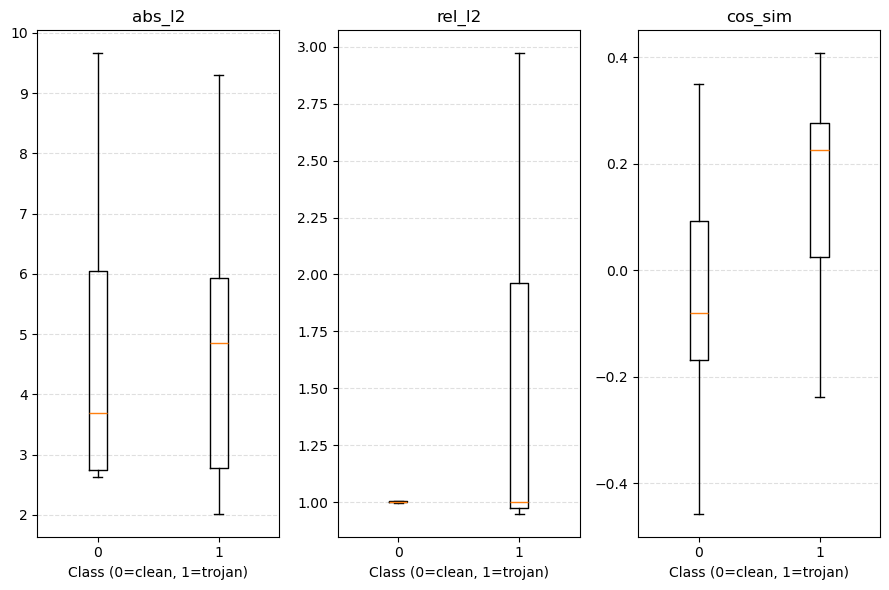

In [8]:
# gbla_trojan_recon_gin.py  (baseline: no defense, fixed to avoid A_t dependency)
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === ATTACK HYPERPARAMS ===
ATTACK_ITERATIONS = 300
ATTACKS_PER_CLASS = 20
DUMMY_LR = 0.1
L2_REG = 0.001
RANDOM_SEED = 42
SAVE_PLOT = "reconstruction_errors_trojan_boxplot_gin.pdf"

# === Set seeds for reproducibility ===
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# === Ensure GIN environment is ready ===
required_names = ["model", "X_t", "y_t", "edge_index_t", "train_mask_t"]
missing = [n for n in required_names if n not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. "
                       f"Run this script after training the GIN model.")

device = next(model.parameters()).device
model.eval()
for p in model.parameters():
    p.requires_grad = True

# === Prepare data ===
train_idx_all = torch.nonzero(train_mask_t & (y_t >= 0), as_tuple=False).view(-1).cpu().numpy().tolist()
train_labels = y_t[train_mask_t].cpu().numpy()
classes_present = np.unique(train_labels).tolist()
rng = np.random.default_rng(RANDOM_SEED)
features_orig = X_t.clone().detach()

# === Initialize metrics containers ===
metrics = {int(c): {"abs_l2": [], "rel_l2": [], "cos_sim": []} for c in classes_present}

# === Attack loop ===
print("Starting GBLA reconstruction attack (GIN)...")

for class_val in classes_present:
    candidate_indices = [int(idx) for idx in train_idx_all if int(y_t[idx].item()) == int(class_val)]
    if len(candidate_indices) == 0:
        print(f" - No candidates for class {class_val}; skipping.")
        continue

    if len(candidate_indices) <= ATTACKS_PER_CLASS:
        target_indices = candidate_indices
    else:
        target_indices = list(rng.choice(candidate_indices, size=ATTACKS_PER_CLASS, replace=False))

    print(f"Attacking class {class_val}: {len(target_indices)} nodes ...")

    for target_idx in target_indices:
        print(f'attacking indices {target_idx}')
        model.zero_grad()

        # --- Step 1: obtain true gradients ---
        logits = model(features_orig.to(device), edge_index_t)
        target_label = y_t[target_idx:target_idx+1].to(device)
        target_loss = nn.CrossEntropyLoss()(logits[target_idx:target_idx+1], target_label)
        target_loss.backward()

        target_grads = []
        for p in model.parameters():
            if p.grad is None:
                target_grads.append(torch.zeros_like(p))
            else:
                target_grads.append(p.grad.detach().clone())

        # --- Step 2: optimize dummy feature ---
        dummy_feat = torch.randn_like(features_orig[target_idx:target_idx+1],
                                      device=device, requires_grad=True)
        dummy_opt = optim.Adam([dummy_feat], lr=DUMMY_LR)

        for it in range(ATTACK_ITERATIONS):
            dummy_features = features_orig.clone().to(device)
            dummy_features[target_idx:target_idx+1] = dummy_feat

            model.zero_grad()
            dummy_logits = model(dummy_features, edge_index_t)
            dummy_loss = nn.CrossEntropyLoss()(dummy_logits[target_idx:target_idx+1], target_label)
            dummy_grads = torch.autograd.grad(dummy_loss,
                                              tuple(model.parameters()),
                                              create_graph=True, allow_unused=True)

            grad_diff_loss = torch.tensor(0.0, device=device)
            for dg, tg in zip(dummy_grads, target_grads):
                if dg is None:
                    dg = torch.zeros_like(tg)
                grad_diff_loss += torch.sum((dg - tg) ** 2)

            reg_loss = torch.norm(dummy_feat, p=2)
            total_loss = grad_diff_loss + L2_REG * reg_loss

            dummy_opt.zero_grad()
            total_loss.backward()
            dummy_opt.step()

        # --- Step 3: compute metrics ---
        orig_feat = features_orig[target_idx:target_idx+1].detach().cpu()
        recon_feat = dummy_feat.detach().cpu()

        abs_l2 = torch.norm(recon_feat - orig_feat, p=2).item()
        rel_l2 = abs_l2 / (torch.norm(orig_feat, p=2).item() + 1e-8)
        cos_sim = torch.nn.functional.cosine_similarity(recon_feat, orig_feat).mean().item()

        metrics[int(class_val)]["abs_l2"].append(abs_l2)
        metrics[int(class_val)]["rel_l2"].append(rel_l2)
        metrics[int(class_val)]["cos_sim"].append(cos_sim)

# === Summary ===
print("\nReconstruction error summary (GIN)")
print("==========================================")
for c, vals in metrics.items():
    for mname, mvals in vals.items():
        if len(mvals) == 0:
            continue
        arr = np.array(mvals)
        print(f" Class {c} | {mname}: mean={arr.mean():.4f}, std={arr.std():.4f}, median={np.median(arr):.4f}")

# === Boxplots ===
plt.figure(figsize=(9,6))
for i, mname in enumerate(["abs_l2", "rel_l2", "cos_sim"], start=1):
    plt.subplot(1,3,i)
    ordered_classes = sorted(metrics.keys())
    data = [metrics[c][mname] for c in ordered_classes]
    plt.boxplot(data, labels=ordered_classes, showfliers=False)
    plt.title(mname)
    plt.xlabel("Class (0=clean, 1=trojan)")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(SAVE_PLOT, dpi=200)
print(f"\nBoxplots saved to: {SAVE_PLOT}")
plt.show()


#### Attack under five defense strategies

Starting multi-defense GBLA attack (GIN)...

--- Defense: none ---
  Class 0: 20 nodes


  Class 1: 20 nodes



--- Defense: dp ---
  Class 0: 20 nodes


  Class 1: 20 nodes



--- Defense: clip ---
  Class 0: 20 nodes


...

  Class 1: 20 nodes



--- Defense: advtrain ---
  Class 0: 20 nodes


  Class 1: 20 nodes


/tmp/ipykernel_113255/2864856476.py:163: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.           
  plt.boxplot(data, labels=defenses, showfliers=False)



Results saved to results_defenses_gin.csv (rows=240)

Summary (mean ± std):
            abs_l2                     rel_l2                   cos_sim  \
              mean        std count      mean       std count      mean   
defense                                                                   
advtrain  4.003895   2.621901    40  1.225678  0.587160    40  0.074989   
clip      3.742078   2.083207    40  1.254295  0.625788    40  0.117035   
dp        4.509231   2.708832    40  1.324677  0.545343    40  0.074394   
none      6.368557  11.325154    40  1.376621  0.698049    40  0.049501   
quant     4.383985   2.739938    40  1.270134  0.575885    40  0.101723   
secure    5.485763   4.773727    40  1.364000  0.618731    40  0.038899   

                          
               std count  
defense                   
advtrain  0.250677    40  
clip      0.230722    40  
dp        0.262950    40  
none      0.211965    40  
quant     0.226347    40  
secure    0.238284    40  

Box

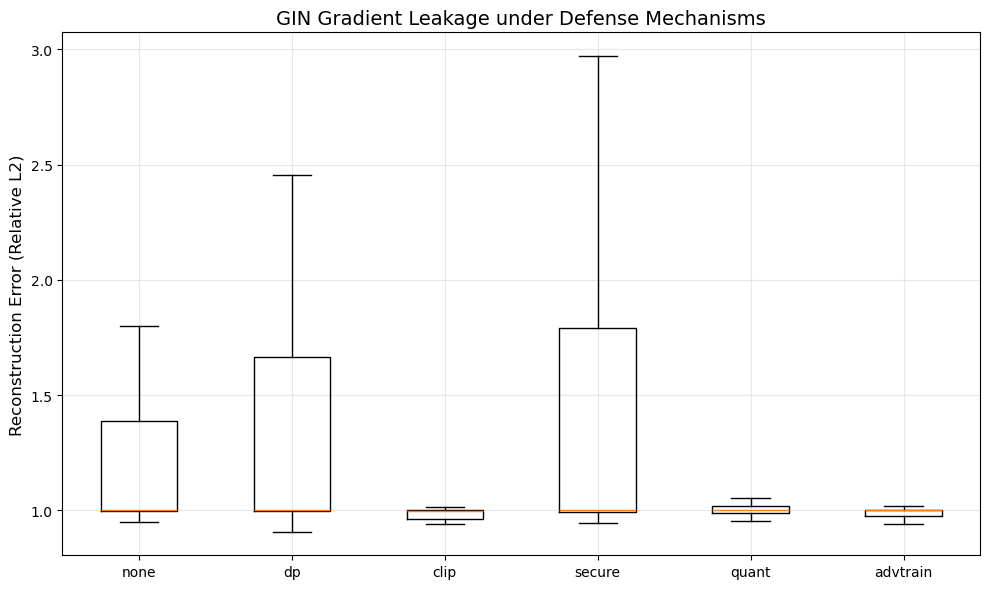

In [9]:
# gbla_trojan_recon_gin_defenses.py
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# === ATTACK HYPERPARAMS ===
ATTACK_ITERATIONS = 300
ATTACKS_PER_CLASS = 20
DUMMY_LR = 0.1
L2_REG = 0.001
RANDOM_SEED = 42
SAVE_CSV = "results_defenses_gin.csv"
SAVE_PLOT = "reconstruction_defenses_boxplot_gin.pdf"

# === Reproducibility ===
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# === Ensure required variables are available ===
required_names = ["model", "X_t", "y_t", "edge_index_t", "train_mask_t"]
missing = [n for n in required_names if n not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. "
                       f"Run this script after training the GIN model.")

device = next(model.parameters()).device
model.eval()
for p in model.parameters():
    p.requires_grad = True

# === Prepare dataset ===
train_idx_all = torch.nonzero(train_mask_t & (y_t >= 0), as_tuple=False).view(-1).cpu().numpy().tolist()
train_labels = y_t[train_mask_t].cpu().numpy()
classes_present = np.unique(train_labels).tolist()
rng = np.random.default_rng(RANDOM_SEED)
features_orig = X_t.clone().detach()

# === Define gradient defenses ===
def apply_defense_to_grads(grads, defense):
    grads_mod = []
    for g in grads:
        if g is None:
            g = torch.zeros_like(grads[0])
        if defense == "dp":        # Differential Privacy noise
            g = g + 0.02 * torch.randn_like(g)
        elif defense == "clip":    # Gradient clipping
            g = torch.clamp(g, -0.5, 0.5)
        elif defense == "secure":  # Secure aggregation (nullify gradients)
            g = torch.zeros_like(g)
        elif defense == "quant":   # Gradient quantization
            g = torch.round(g * 10) / 10
        elif defense == "advtrain": # Adversarial noise
            g = g + 0.01 * torch.sign(torch.randn_like(g))
        grads_mod.append(g.detach())
    return grads_mod

# === Defenses to test ===
defenses = ["none", "dp", "clip", "secure", "quant", "advtrain"]
results = []

print("Starting multi-defense GBLA attack (GIN)...")

# === Main attack loop ===
for defense in defenses:
    print(f"\n--- Defense: {defense} ---")
    for class_val in classes_present:
        candidate_indices = [int(idx) for idx in train_idx_all if int(y_t[idx].item()) == int(class_val)]
        if len(candidate_indices) == 0:
            print(f" - No candidates for class {class_val}; skipping.")
            continue

        if len(candidate_indices) <= ATTACKS_PER_CLASS:
            target_indices = candidate_indices
        else:
            target_indices = list(rng.choice(candidate_indices, size=ATTACKS_PER_CLASS, replace=False))

        print(f"  Class {class_val}: {len(target_indices)} nodes")

        for target_idx in tqdm(target_indices, desc=f"{defense} | Class {class_val}", leave=False):
            model.zero_grad()

            # --- Step 1: True gradients ---
            logits = model(features_orig.to(device), edge_index_t)
            target_label = y_t[target_idx:target_idx+1].to(device)
            target_loss = nn.CrossEntropyLoss()(logits[target_idx:target_idx+1], target_label)
            target_loss.backward()

            target_grads = []
            for p in model.parameters():
                if p.grad is None:
                    target_grads.append(torch.zeros_like(p))
                else:
                    target_grads.append(p.grad.detach().clone())

            # --- Step 2: Apply defense ---
            grads_used = target_grads if defense == "none" else apply_defense_to_grads(target_grads, defense)

            # --- Step 3: Optimize dummy feature to reconstruct ---
            dummy_feat = torch.randn_like(features_orig[target_idx:target_idx+1],
                                          device=device, requires_grad=True)
            dummy_opt = optim.Adam([dummy_feat], lr=DUMMY_LR)

            for it in range(ATTACK_ITERATIONS):
                dummy_features = features_orig.clone().to(device)
                dummy_features[target_idx:target_idx+1] = dummy_feat

                model.zero_grad()
                dummy_logits = model(dummy_features, edge_index_t)
                dummy_loss = nn.CrossEntropyLoss()(dummy_logits[target_idx:target_idx+1], target_label)
                dummy_grads = torch.autograd.grad(dummy_loss, tuple(model.parameters()),
                                                  create_graph=True, allow_unused=True)

                grad_diff_loss = torch.tensor(0.0, device=device)
                for dg, tg in zip(dummy_grads, grads_used):
                    if dg is None:
                        dg = torch.zeros_like(tg)
                    grad_diff_loss += torch.sum((dg - tg) ** 2)

                reg_loss = torch.norm(dummy_feat, p=2)
                total_loss = grad_diff_loss + L2_REG * reg_loss

                dummy_opt.zero_grad()
                total_loss.backward()
                dummy_opt.step()

            # --- Step 4: Evaluate reconstruction ---
            orig_feat = features_orig[target_idx:target_idx+1].detach().cpu()
            recon_feat = dummy_feat.detach().cpu()
            abs_l2 = torch.norm(recon_feat - orig_feat, p=2).item()
            rel_l2 = abs_l2 / (torch.norm(orig_feat, p=2).item() + 1e-8)
            cos_sim = F.cosine_similarity(recon_feat, orig_feat).mean().item()

            results.append({
                "defense": defense,
                "class": int(class_val),
                "node_idx": int(target_idx),
                "abs_l2": abs_l2,
                "rel_l2": rel_l2,
                "cos_sim": cos_sim
            })

# === Save results ===
df_def = pd.DataFrame(results)
df_def.to_csv(SAVE_CSV, index=False)
print(f"\nResults saved to {SAVE_CSV} (rows={len(df_def)})")

# === Summary ===
print("\nSummary (mean ± std):")
summary = df_def.groupby("defense")[["abs_l2", "rel_l2", "cos_sim"]].agg(["mean", "std", "count"])
print(summary)

# === Boxplots ===
plt.figure(figsize=(10,6))
data = [df_def[df_def["defense"]==d]["rel_l2"].values for d in defenses]
plt.boxplot(data, labels=defenses, showfliers=False)
plt.ylabel("Reconstruction Error (Relative L2)", fontsize=12)
plt.title("GIN Gradient Leakage under Defense Mechanisms", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_PLOT, dpi=200)
print(f"\nBoxplots saved to: {SAVE_PLOT}")
plt.show()


In [10]:
# === Per-class Summary ===
print("\nDetailed per-class summary (mean ± std):")
class_summary = (
    df_def.groupby(["defense", "class"])[["abs_l2", "rel_l2", "cos_sim"]]
    .agg(["mean", "std", "count"])
    .reset_index()
)

for d in defenses:
    print(f"\n--- Defense: {d} ---")
    for c in sorted(df_def["class"].unique()):
        sub = class_summary[(class_summary["defense"] == d) & (class_summary["class"] == c)]
        if sub.empty:
            print(f"  Class {c}: No data")
            continue
        row = sub.iloc[0]
        cname = "clean" if c == 0 else "trojan"
        print(f"  {cname:7s} | abs_l2 = {row[('abs_l2','mean')]:.4f} ± {row[('abs_l2','std')]:.4f} "
              f"| rel_l2 = {row[('rel_l2','mean')]:.4f} ± {row[('rel_l2','std')]:.4f} "
              f"| cos_sim = {row[('cos_sim','mean')]:.4f} ± {row[('cos_sim','std')]:.4f} "
              f"(n={int(row[('abs_l2','count')])})")



Detailed per-class summary (mean ± std):

--- Defense: none ---
  clean   | abs_l2 = 4.6625 ± 2.1868 | rel_l2 = 1.2015 ± 0.4705 | cos_sim = -0.0527 ± 0.1822 (n=20)
  trojan  | abs_l2 = 8.0746 ± 15.8858 | rel_l2 = 1.5517 ± 0.8451 | cos_sim = 0.1517 ± 0.1924 (n=20)

--- Defense: dp ---
  clean   | abs_l2 = 4.3303 ± 2.3500 | rel_l2 = 1.2386 ± 0.5019 | cos_sim = -0.0245 ± 0.2488 (n=20)
  trojan  | abs_l2 = 4.6881 ± 3.0776 | rel_l2 = 1.4107 ± 0.5856 | cos_sim = 0.1732 ± 0.2438 (n=20)

--- Defense: clip ---
  clean   | abs_l2 = 3.9287 ± 1.4484 | rel_l2 = 1.1894 ± 0.4663 | cos_sim = -0.0245 ± 0.1801 (n=20)
  trojan  | abs_l2 = 3.5555 ± 2.5955 | rel_l2 = 1.3192 ± 0.7600 | cos_sim = 0.2586 ± 0.1862 (n=20)

--- Defense: secure ---
  clean   | abs_l2 = 5.5497 ± 2.1920 | rel_l2 = 1.3562 ± 0.6377 | cos_sim = -0.0975 ± 0.2004 (n=20)
  trojan  | abs_l2 = 5.4218 ± 6.4779 | rel_l2 = 1.3718 ± 0.6157 | cos_sim = 0.1753 ± 0.1929 (n=20)

--- Defense: quant ---
  clean   | abs_l2 = 3.9852 ± 2.2213 | rel_l2